In [ ]:
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONEXIÓN A GOOGLE DRIVE
# Conectamos Google Drive para que la libreta pueda acceder a las carpetas
# donde guardaron sus ihmágenes preprocesadas.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Aquí deben poner la ruta exacta a la carpeta principal de sus flores en Drive.
# Adentro de esta carpeta debe haber 5 subcarpetas (daisy, dandelion, rose, etc.)
DATASET_DIR = RUTA_DATOS = "/content/dataset_segmentado/flowers_segmented"


Mostrando imágenes de muestra del dataset...


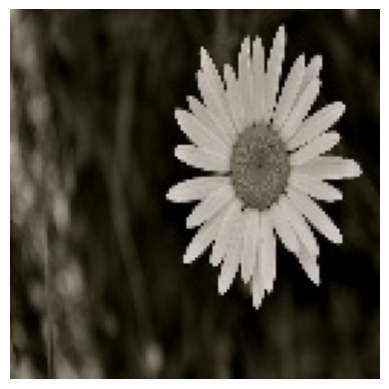

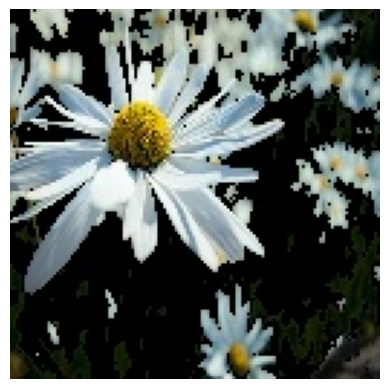

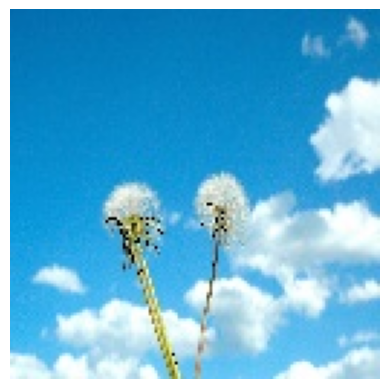

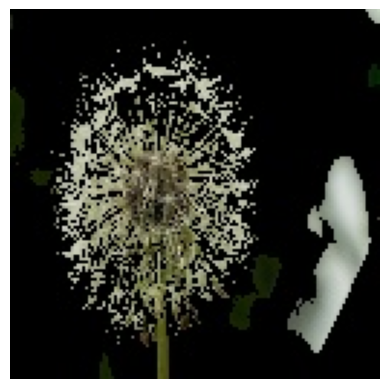

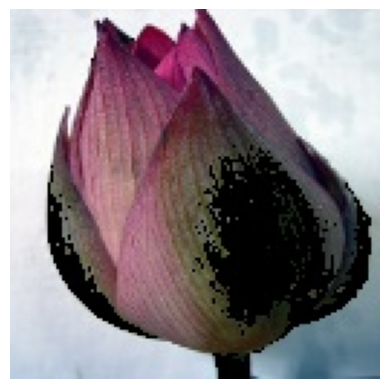

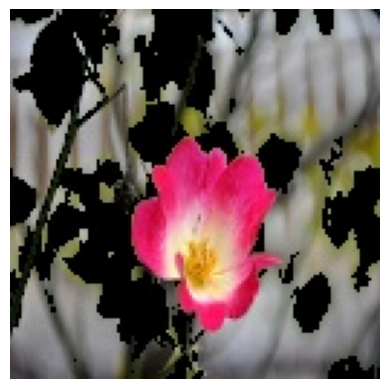

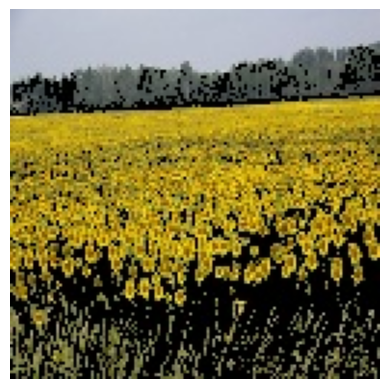

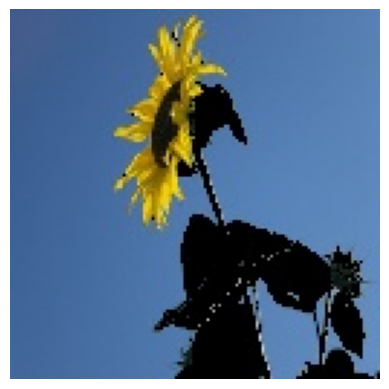

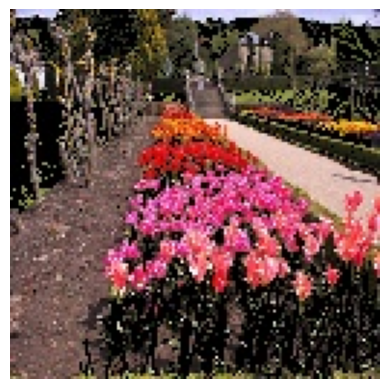

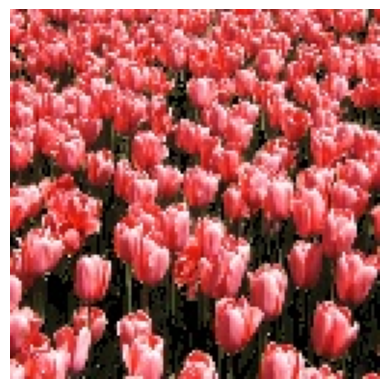

In [ ]:

# 2. VISUALIZACIÓN DE IMÁGENES DE MUESTRA
# ¿Qué hace?: Toma 2 imágenes al azar de cada clase y las imprime en pantalla.
# ¿Para qué sirve?: Ayuda a comprobar visualmente que las rutas están bien
# conectadas y que las imágenes sí sufrieron el preprocesamiento que programaron.
print("\nMostrando imágenes de muestra del dataset...")
daisy_dir = os.path.join(DATASET_DIR, 'daisy')
dandelion_dir = os.path.join(DATASET_DIR, 'dandelion')
rose_dir = os.path.join(DATASET_DIR, 'rose')
sunflower_dir = os.path.join(DATASET_DIR, 'sunflower')
tulip_dir = os.path.join(DATASET_DIR, 'tulip')

daisy_files = os.listdir(daisy_dir)
dandelion_files = os.listdir(dandelion_dir)
rose_files = os.listdir(rose_dir)
sunflower_files = os.listdir(sunflower_dir)
tulip_files = os.listdir(tulip_dir)

pic_index = 2

# Seleccionamos las imágenes para mostrarlas
next_daisy = [os.path.join(daisy_dir, fname) for fname in daisy_files[pic_index-2:pic_index]]
next_dandelion = [os.path.join(dandelion_dir, fname) for fname in dandelion_files[pic_index-2:pic_index]]
next_rose = [os.path.join(rose_dir, fname) for fname in rose_files[pic_index-2:pic_index]]
next_sunflower = [os.path.join(sunflower_dir, fname) for fname in sunflower_files[pic_index-2:pic_index]]
next_tulip = [os.path.join(tulip_dir, fname) for fname in tulip_files[pic_index-2:pic_index]]

for i, img_path in enumerate(next_daisy + next_dandelion + next_rose + next_sunflower + next_tulip):
  img = mpimg.imread(img_path)
  plt.imshow(img)
  plt.axis('Off')
  plt.show()


In [ ]:

# 3. GENERADORES DE IMÁGENES Y DATA AUGMENTATION (AUMENTO DE DATOS)
# ¿Qué hace?: En lugar de cargar todas las imágenes de golpe en la memoria RAM,
# las carga por "lotes". Además, les aplica transformaciones aleatorias (rotar,
# hacer zoom, voltear).
# ¿Para qué sirve?: Evita el "Overfitting" (sobreajuste), forzando a la red a
# aprender características robustas y no solo a memorizar la foto original.

# Generador para ENTRENAMIENTO (Con transformaciones y separación del 80%)
training_datagen = ImageDataGenerator(
      rescale = 1./255,          # Normaliza los píxeles de 0-255 a 0-1
      rotation_range=40,         # Rota la imagen aleatoriamente hasta 40 grados
      width_shift_range=0.2,     # Mueve la imagen horizontalmente
      height_shift_range=0.2,    # Mueve la imagen verticalmente
      shear_range=0.2,           # Deforma la imagen
      zoom_range=0.2,            # Aplica zoom aleatorio
      horizontal_flip=True,      # Voltea la imagen como en un espejo
      fill_mode='nearest',       # Rellena los huecos vacíos tras rotar
      validation_split=0.2)      #  APARTA EL 20% DE LOS DATOS PARA VALIDACIÓN

train_generator = training_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(150,150),       # Redimensiona todo a 150x150 píxeles
    class_mode='categorical',    # Indica que hay más de 2 clases
    subset='training'            # Usa el 80% reservado para entrenar
)

# Generador para VALIDACIÓN (Sin transformaciones, solo normalizado)
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2)

validation_generator = validation_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(150,150),
    class_mode='categorical',
    subset='validation',         # Usa el 20% reservado para validar
    shuffle=False                # NO REVOLVER: vital para que la matriz de confusión cuadre
)



Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.


In [ ]:
# 4. ARQUITECTURA DE LA RED NEURONAL CONVOLUCIONAL (CNN)
# ¿Qué hace?: Define la estructura del "cerebro" que va a aprender.
# Las capas Conv2D extraen características (bordes, texturas, colores).
# Las capas MaxPooling reducen el tamaño de la imagen, quedándose con lo más importante.
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(150, 150, 3)), # Imágenes de 150x150 con 3 canales (RGB)

    # 4 Bloques Convolucionales
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Aplanamos los mapas de características para pasarlos a las neuronas tradicionales
    tf.keras.layers.Flatten(),

    # Capa Dropout: Apaga el 50% de las neuronas al azar en cada paso para evitar sobreajuste
    tf.keras.layers.Dropout(0.5),

    # Capa Oculta Densa
    tf.keras.layers.Dense(512, activation='relu'),

    # Capa de Salida: Tiene tantas neuronas como clases (flores) haya detectado.
    # Softmax convierte los resultados en probabilidades (ej. 80% rosa, 20% tulipán).
    tf.keras.layers.Dense(len(train_generator.class_indices), activation='softmax')
])

model.summary() # Imprime el resumen de la arquitectura



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,474,501 (13.25 MB)

 Trainable params: 3,474,501 (13.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# 5. COMPILACIÓN Y ENTRENAMIENTO
# Compilar: Le decimos al modelo cómo va a medir sus errores (categorical_crossentropy)
# y cómo va a ajustar sus pesos para mejorar (optimizador rmsprop).
model.compile(loss = 'categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

# Entrenar: La red empieza a ver las imágenes y a aprender durante 25 "vueltas" (épocas).
#Epocas es el único parámetro que pueden modificar
history = model.fit(train_generator, epochs=25, validation_data = validation_generator, verbose = 1)

# Guardamos el modelo entrenado por si queremos usarlo después sin reentrenar
model.save("flores.h5")

Epoch 1/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 33s 265ms/step - accuracy: 0.3454 - loss: 1.5149 - val_accuracy: 0.4686 - val_loss: 1.1842
Epoch 2/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 225ms/step - accuracy: 0.5097 - loss: 1.1761 - val_accuracy: 0.4105 - val_loss: 1.4400
Epoch 3/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 228ms/step - accuracy: 0.5615 - loss: 1.1059 - val_accuracy: 0.5791 - val_loss: 1.0744
Epoch 4/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 27s 242ms/step - accuracy: 0.5846 - loss: 1.0401 - val_accuracy: 0.6047 - val_loss: 0.9975
Epoch 5/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 26s 237ms/step - accuracy: 0.6153 - loss: 0.9940 - val_accuracy: 0.6337 - val_loss: 0.9659
Epoch 6/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 226ms/step - accuracy: 0.6213 - loss: 0.9729 - val_accuracy: 0.6721 - val_loss: 0.8838
Epoch 7/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 228ms/step - accuracy: 0.6509 - loss: 0.9226 - val_accuracy: 0.6860 - val_loss: 0.8640
Epoch 8/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 26s 237ms/step - accuracy: 0.6578 - loss: 0

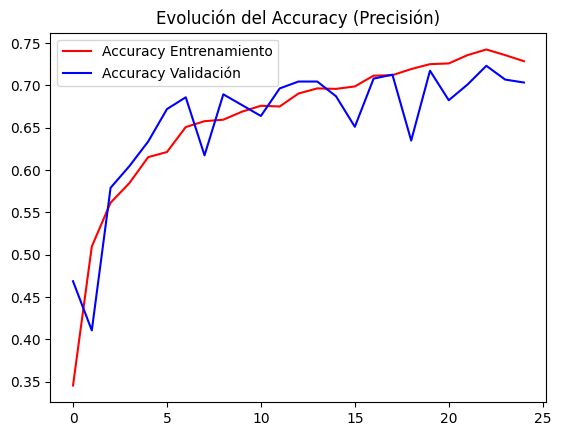

<Figure size 640x480 with 0 Axes>

In [ ]:
# 6. GRÁFICAS DE ENTRENAMIENTO (ACCURACY Y LOSS)
# ¿Para qué sirve?: Nos permite ver si el modelo realmente aprendió o si se estancó.
# Si la línea roja (Entrenamiento) sube mucho, pero la azul (Validación) baja o se separa,
# significa que el modelo está memorizando (Overfitting).
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Accuracy Entrenamiento')
plt.plot(epochs, val_acc, 'b', label='Accuracy Validación')
plt.title('Evolución del Accuracy (Precisión)')
plt.legend(loc=0)
plt.figure()
plt.show()




--- GENERANDO MÉTRICAS PARA EL REPORTE ---
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step

Reporte de Clasificación (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

       daisy       0.91      0.74      0.81       152
   dandelion       0.86      0.59      0.70       210
        rose       0.74      0.46      0.57       156
   sunflower       0.61      0.92      0.73       146
       tulip       0.59      0.83      0.69       196

    accuracy                           0.70       860
   macro avg       0.74      0.71      0.70       860
weighted avg       0.74      0.70      0.70       860



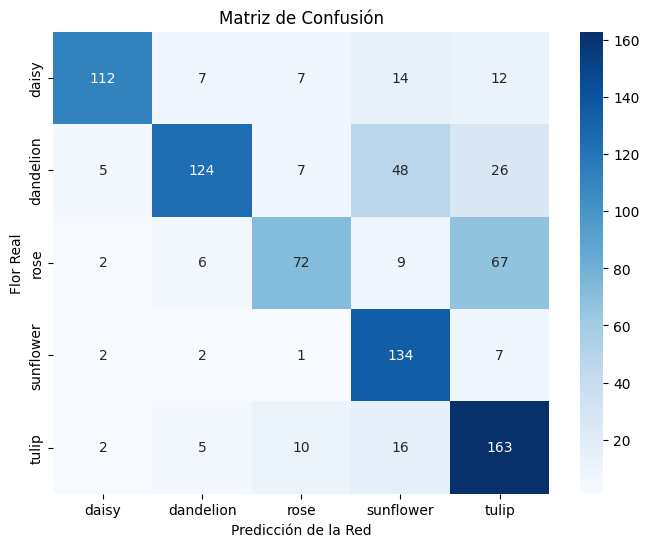

In [ ]:
# 7. MATRIZ DE CONFUSIÓN Y REPORTE DE CLASIFICACIÓN
# ¿Qué hace?: Evalúa matemáticamente el desempeño de la red en datos que nunca había visto.
# La matriz de confusión nos dice exactamente qué flor confundió con cuál otra.
print("\n--- GENERANDO MÉTRICAS PARA EL REPORTE ---")

nombres_clases = list(train_generator.class_indices.keys())
y_true = validation_generator.classes               # Las etiquetas reales
predicciones_val = model.predict(validation_generator) # Lo que la red cree que son
y_pred = np.argmax(predicciones_val, axis=1)        # Tomamos la probabilidad más alta

print("\nReporte de Clasificación (Precision, Recall, F1-Score):")
# Este reporte muestra métricas detalladas por cada clase individual
print(classification_report(y_true, y_pred, target_names=nombres_clases))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión')
plt.ylabel('Flor Real')
plt.xlabel('Predicción de la Red')
plt.show()



--- PRUEBA INTERACTIVA ---
Sube una foto de una flor desde tu computadora para clasificarla:


Saving flormuestra.png to flormuestra (2).png


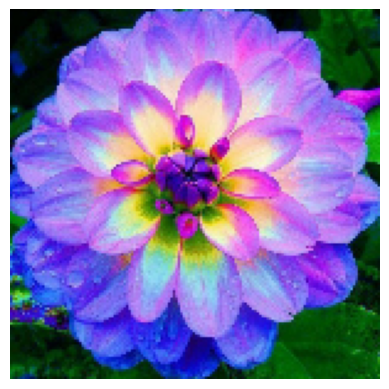

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step
La red neuronal predice que es: TULIP


In [ ]:
# 8. PRUEBA INTERACTIVA (CARGAR IMAGEN MANUAL)
# ¿Para qué sirve?: Es la prueba final. Permite al usuario subir una foto
# que tenga descargada en su computadora para ver qué responde la red neuronal.
print("\n--- PRUEBA INTERACTIVA ---")
print("Sube una foto de una flor desde tu computadora para clasificarla:")

subidas = files.upload()
resultado = nombres_clases

for mi_imagen in subidas.keys():
  ruta = mi_imagen
  # Cargamos la imagen al tamaño que exige la red (150x150)
  img = image.load_img(ruta, target_size=(150, 150))
  plt.imshow(img)
  plt.axis('Off')
  plt.show()

  # Convertimos la imagen en un arreglo matemático de píxeles
  img_array = image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0) # Añadimos una dimensión extra (batch)
  imagen_a_predecir = np.vstack([img_array])

  # Hacemos la predicción pasándole el arreglo a la red
  predicciones = model.predict(imagen_a_predecir, batch_size=10)

  # Buscamos el índice con la probabilidad más alta
  indice_clase_predicha = np.argmax(predicciones, axis=1)[0]
  print(f"La red neuronal predice que es: {resultado[indice_clase_predicha].upper()}")